In [4]:
import pandas as pd
df=pd.read_csv("Wholesale customers data.csv")
df

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185
...,...,...,...,...,...,...,...,...
435,1,3,29703,12051,16027,13135,182,2204
436,1,3,39228,1431,764,4510,93,2346
437,2,3,14531,15488,30243,437,14841,1867
438,1,3,10290,1981,2232,1038,168,2125


In [5]:
df.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


In [6]:
df.tail()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
435,1,3,29703,12051,16027,13135,182,2204
436,1,3,39228,1431,764,4510,93,2346
437,2,3,14531,15488,30243,437,14841,1867
438,1,3,10290,1981,2232,1038,168,2125
439,1,3,2787,1698,2510,65,477,52


In [7]:
df.columns

Index(['Channel', 'Region', 'Fresh', 'Milk', 'Grocery', 'Frozen',
       'Detergents_Paper', 'Delicassen'],
      dtype='object')

In [8]:
df['Channel'].unique()

array([2, 1])

In [9]:
df['Region'].unique()

array([3, 1, 2])

In [10]:
df.sample(5)

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
412,1,3,97,3605,12400,98,2970,62
28,2,3,4113,20484,25957,1158,8604,5206
76,1,3,717,3587,6532,7530,529,894
433,1,3,1982,3218,1493,1541,356,1449
405,1,3,6884,1046,1167,2069,593,378


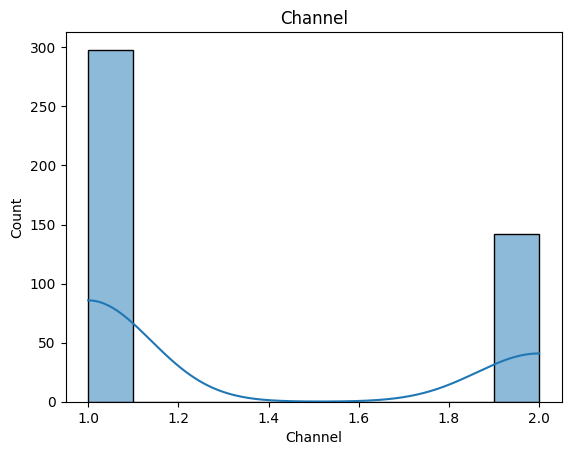

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(df["Channel"],kde=True)
plt.title("Channel")
plt.show()

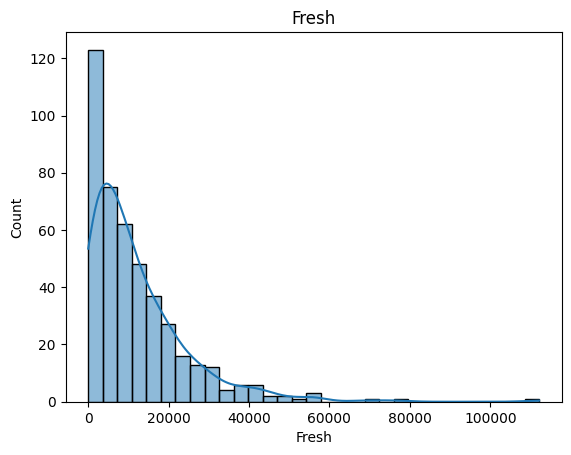

In [12]:
sns.histplot(df['Fresh'],kde=True)
plt.title("Fresh")
plt.show()

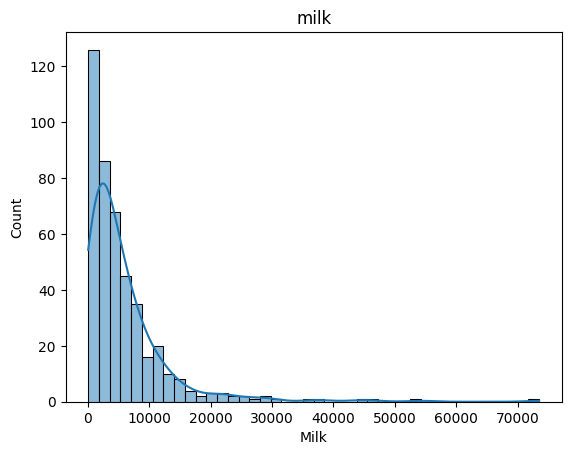

In [13]:
sns.histplot(df['Milk'],kde=True)
plt.title("milk")
plt.show()

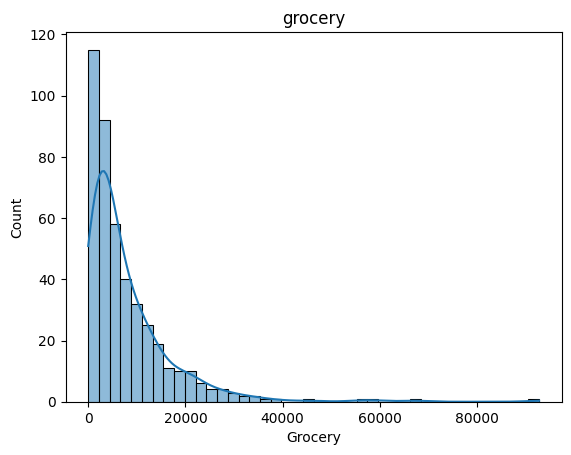

In [14]:
sns.histplot(df['Grocery'],kde=True)
plt.title("grocery")
plt.show()

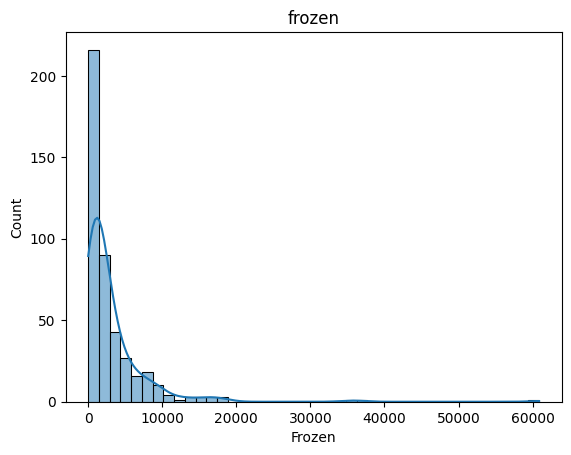

In [15]:
sns.histplot(df['Frozen'],kde=True)
plt.title("frozen")
plt.show()

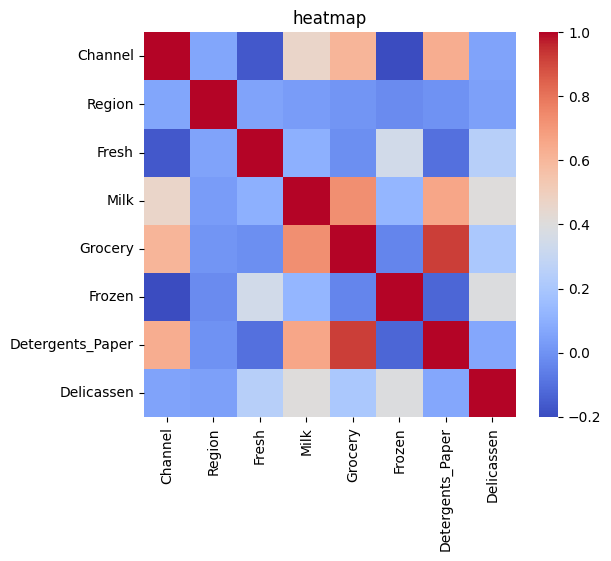

In [16]:
corr=df.corr()
plt.figure(figsize=(6,5))
sns.heatmap(corr,fmt=".2f",cmap="coolwarm")
plt.title("heatmap")
plt.show()

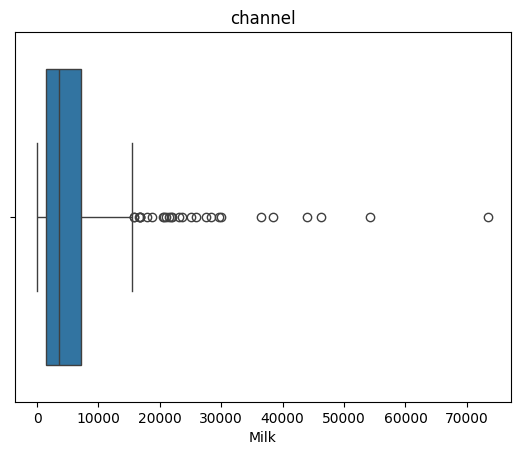

In [17]:
sns.boxplot(x=df['Milk'])
plt.title("channel")
plt.show()

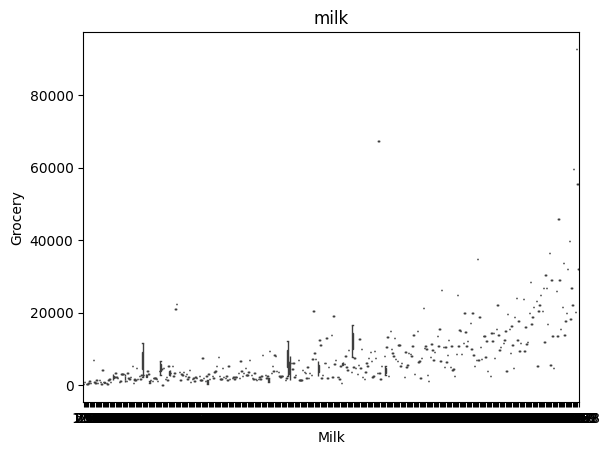

In [18]:
sns.boxplot(data=df,x="Milk",y="Grocery")
plt.title("milk")
plt.show()

In [19]:
df.columns

Index(['Channel', 'Region', 'Fresh', 'Milk', 'Grocery', 'Frozen',
       'Detergents_Paper', 'Delicassen'],
      dtype='object')

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import silhouette_score

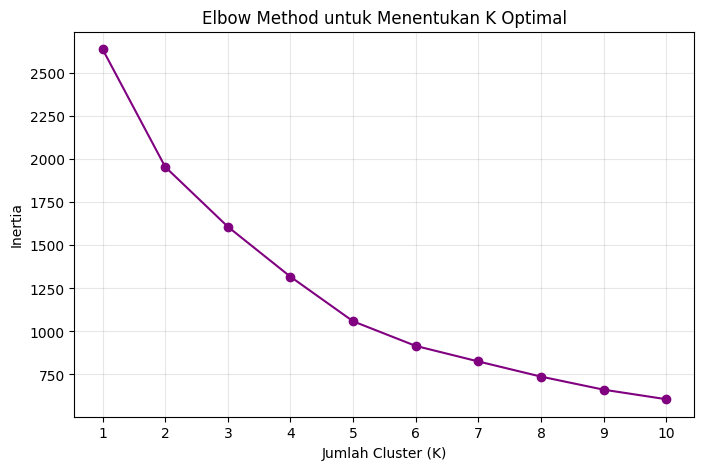

→ Elbow biasanya terlihat di sekitar K=3 pada dataset ini.



In [21]:
# -----------------------------
# Blok 4: Elbow Method (tanpa warning)
# -----------------------------
X = df[[ 'Fresh', 'Milk', 'Grocery', 'Frozen','Detergents_Paper', 'Delicassen']]
X_array = X.to_numpy()              # Konversi ke numpy array sejak awal

scaler_temp = StandardScaler()
X_scaled = scaler_temp.fit_transform(X_array)

inertias = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertias, marker='o', color='purple')
plt.xlabel("Jumlah Cluster (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method untuk Menentukan K Optimal")
plt.grid(True, alpha=0.3)
plt.xticks(K_range)
plt.show()

print("→ Elbow biasanya terlihat di sekitar K=3 pada dataset ini.\n")


# -----------------------------

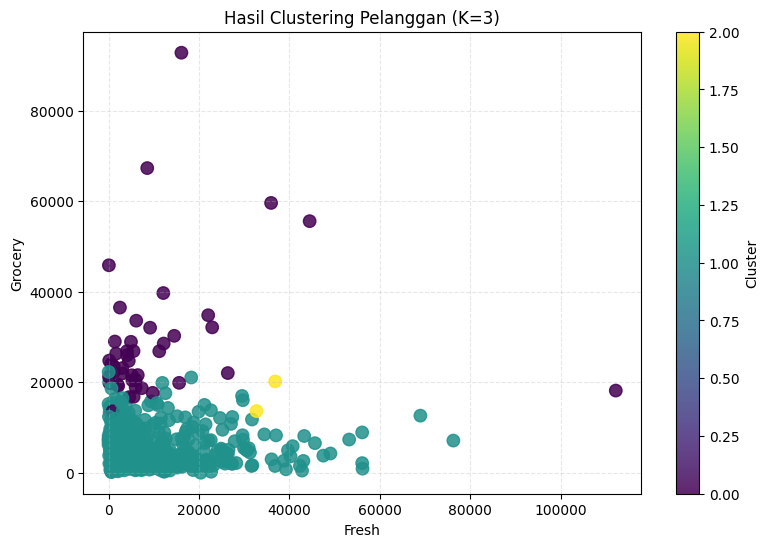


Rata-rata per Cluster:
           Fresh     Milk  Grocery   Frozen  Detergents_Paper  Delicassen
cluster                                                                  
0        10441.0  19386.0  28656.0   2190.0           13328.0      2374.0
1        12063.0   4115.0   5535.0   2941.0            1696.0      1299.0
2        34782.0  30367.0  16898.0  48702.0             756.0     26776.0
None


In [22]:
# Blok 5: Pipeline Clustering + Visualisasi Hasil (tanpa warning)
# -----------------------------
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('kmeans', KMeans(n_clusters=3, random_state=42, n_init=10))
])

# Fit dengan numpy array → scaler tidak simpan nama kolom → NO WARNING
pipeline.fit(X_array)

# Label cluster
labels = pipeline.named_steps['kmeans'].labels_

# Tambah ke df untuk analisis & visualisasi
df['cluster'] = labels

# Visualisasi hasil clustering
plt.figure(figsize=(9, 6))
scatter = plt.scatter( 
    df['Fresh'],
    df['Grocery'], 
    c=labels,
    cmap='viridis',
    s=80,
    alpha=0.85
)
plt.xlabel("Fresh")
plt.ylabel("Grocery")
plt.title("Hasil Clustering Pelanggan (K=3)")
plt.colorbar(scatter, label='Cluster')
plt.grid(True, linestyle="--", alpha=0.3)
plt.show()

# Ringkasan rata-rata per cluster
print("\nRata-rata per Cluster:")
print(print(df.groupby('cluster')[['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']].mean().round(0)))

In [23]:
# Blok 6: Silhouette Score (tanpa warning)
# -----------------------------
# Transform pakai numpy array yang sama
X_scaled_final = pipeline.named_steps['scaler'].transform(X_array)

sil_score = silhouette_score(X_scaled_final, labels)
print(f"\nSilhouette Score (K=3): {sil_score:.4f}")

if sil_score > 0.5:
    print("→ Cluster cukup terpisah dengan baik")
elif sil_score > 0.3:
    print("→ Cluster cukup wajar (ada sedikit overlap)")
else:
    print("→ Cluster kurang optimal, coba ubah jumlah K")


# -----------------------------


Silhouette Score (K=3): 0.5483
→ Cluster cukup terpisah dengan baik


In [24]:
# Blok 7: Prediksi Data Baru (tanpa warning)
# -----------------------------
data_baru = np.array([
    [30, 3_000_000],    # usia 30, pengeluaran 3 jt
    [42, 5_500_000],    # contoh menengah
    [65, 12_000_000]    # contoh tua tinggi
])

pred_clusters = pipeline.predict(data_baru)

print("\n=== Prediksi Data Baru ===")
for i, row in enumerate(data_baru):
    usia, peng = row
    print(f"Usia {usia} th, Pengeluaran Rp{peng:,} → Cluster {pred_clusters[i]}")

ValueError: X has 2 features, but StandardScaler is expecting 6 features as input.